In [3]:
import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn  # Import neural network module
import torch.optim as optim  # Import optimization module
import src
from src.data.synthetic_data import SyntheticDataGenerator
from src.data.dataset import KineticDataset, Normalize
from src.data.data_loader import get_data_loaders
from src.models.crnn import CRNN
from src.models.loss_fn import RangeNormalizedMAE, RangeNormalizedMSE
from src.models.train_tune import train
import json
# For one step reaction
y0 = {
    'S_1' : (20, 60),
    'S_2' : (100, 100),
    'S_out' : (0, 0),
}
ks = [2e2*1e-9]
E_bounds = (-np.inf, np.inf)

time_hours = 1 #hours
t_end = time_hours * 3600  # seconds

data_gen = SyntheticDataGenerator(
    mechanism='one_step',
    reaction_rates=ks,
    initial_concentration_ranges=y0,
    noise_level=0,
    t_end=t_end,
    n_timepoints = t_end//30,  # every 30 seconds
    seed=42,
    E_bounds=E_bounds
)

batch_size = 3
batch = data_gen.generate_batch(batch_size)
norm = Normalize(max_concentration=torch.max(batch["c0"]))

ds = KineticDataset(batch, transform=norm)


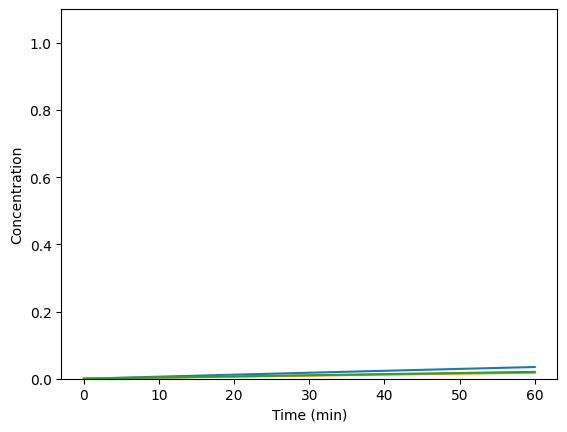

c0: <built-in method numpy of Tensor object at 0x7f17893fa670>, E: 224475.89465488252
c0: <built-in method numpy of Tensor object at 0x7f17892a7340>, E: 224516.84153969045
c0: <built-in method numpy of Tensor object at 0x7f1787066990>, E: 224510.64948634797


In [4]:
# Visualize kinetics for each sample on a single plot
t = ds.get_t().numpy()
for i in range(batch_size):
    sample = ds[i]
    y = sample['y'].numpy()
    
    plt.plot(t/60, y, label=f'Sample {i}')
plt.xlabel('Time (min)')
plt.ylabel('Concentration')
plt.ylim(0, 1.1)
plt.show()

for d in ds:
    c0 = d['c0']
    E = data_gen._E_from_fim(data_gen._SVD(data_gen._compute_fim_output(c0, summed = True)))
    print(f"c0: {c0.numpy}, E: {E}")

In [5]:
#hyperparameters
config = json.load(open('config.json'))
config["num_reactions"] = 1

## Known species experiment

In [6]:
train_loss, val_loss, model, test_loader = train(config, ds)

Epoch 0: Train Loss: 0.017707, Val Loss: 0.008962
Epoch 100: Train Loss: 0.000076, Val Loss: 0.001786
Epoch 200: Train Loss: 0.000074, Val Loss: 0.000578
Epoch 300: Train Loss: 0.000048, Val Loss: 0.000574
Epoch 400: Train Loss: 0.000062, Val Loss: 0.000731
Early stopping at epoch 496
Final training loss: 0.000044, validation loss: 0.000514


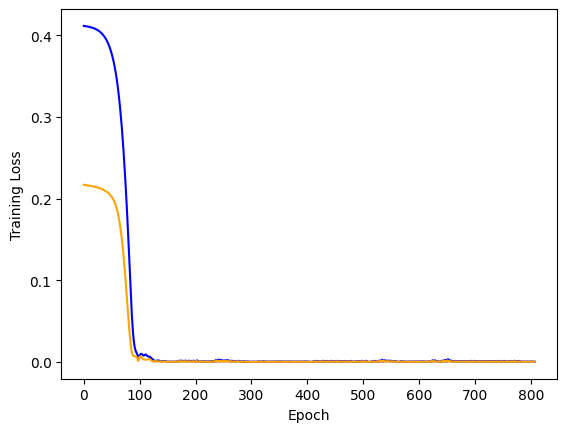

Learned Reaction stoichiometry
[[-0.99980545]
 [-0.99980533]
 [ 0.99980545]]
Learned reaction rates: [19738.08007812]


In [35]:
params = (model.nu().detach().cpu().numpy(), model.log_k.detach().cpu().numpy())
norm_value = ds.transform.max_c0.item()
k = np.exp(params[1])  # in M^-1 s^-1
k_normed = np.zeros(k.shape)
nu = params[0]
for i_col in range(nu.shape[1]):
    react_weights = [v for v in nu[:, i_col] if v > 0]
    order = np.sum(react_weights)
    k_normed[i_col] = k[i_col] * ((1e9/norm_value) **(order - 1))
plt.plot(train_loss, color = "blue")
plt.plot(val_loss, color = "orange")
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned Reaction stoichiometry')
print(-1*nu)  # neg
print('Learned reaction rates:', k_normed)  # in M^-1 s^-1

- 7000: bad
- 100000: good
- 200000: good


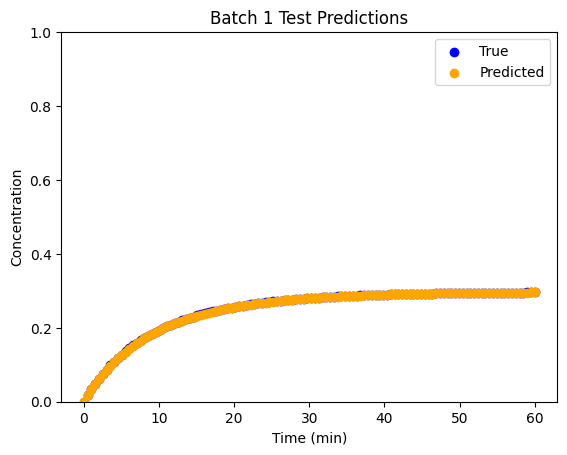

In [36]:
# Plot test predictions over test loader
model.eval()
t_train = ds.get_t()
out_ind = ds.get_output_index()  # index of output species
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"]
        y_true = batch["y"]

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.ylim(0,1)
        plt.legend()
        plt.show()

## Redundant species added

In [8]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 0, 1],
    [0, 1, 1, 0],
    [0, 1, 0, 1]
])       # for scipy.null_spa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true)
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.334708
Epoch 11/500 | loss 0.235597
Epoch 21/500 | loss 0.134362
Epoch 31/500 | loss 0.051903
Epoch 41/500 | loss 0.015257
Epoch 51/500 | loss 0.014001
Epoch 61/500 | loss 0.011161
Epoch 71/500 | loss 0.004577
Epoch 81/500 | loss 0.005536
Epoch 91/500 | loss 0.002772
Epoch 101/500 | loss 0.000373
Epoch 111/500 | loss 0.000677
Epoch 121/500 | loss 0.000416
Epoch 131/500 | loss 0.000110
Epoch 141/500 | loss 0.000226
Epoch 151/500 | loss 0.000629
Epoch 161/500 | loss 0.000663
Epoch 171/500 | loss 0.000311
Epoch 181/500 | loss 0.000903
Epoch 191/500 | loss 0.000092
Epoch 201/500 | loss 0.000038
Epoch 211/500 | loss 0.000207
Epoch 221/500 | loss 0.000452
Epoch 231/500 | loss 0.000757
Epoch 241/500 | loss 0.000219
Epoch 251/500 | loss 0.001459
Epoch 261/500 | loss 0.000152
Epoch 271/500 | loss 0.000597
Epoch 281/500 | loss 0.000518
Epoch 291/500 | loss 0.000104
Epoch 301/500 | loss 0.000465
Epoch 311/500 | loss 0.000430
Epoch 321/500 | loss 0.000038
Epoch 331/500 | loss 

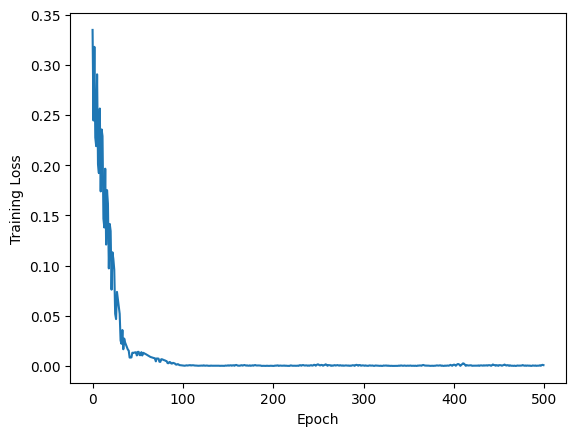

Learned reaction rates: [19988.107]
Reaction stoiciometry
[[-1.0004433]
 [-1.0004433]
 [ 1.0004433]
 [ 1.0004433]]


In [9]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

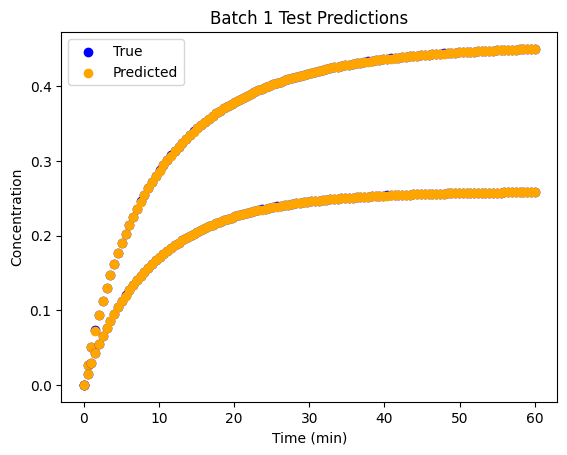

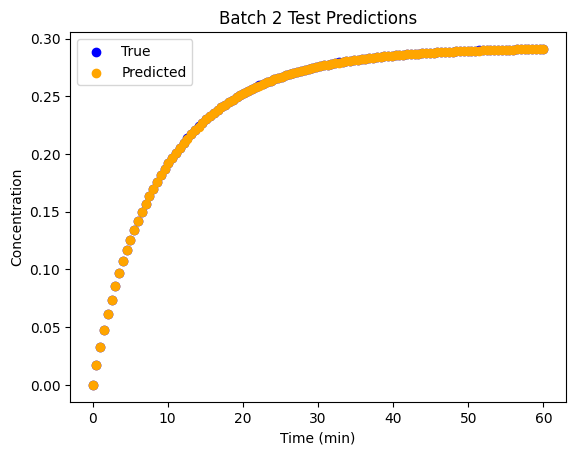

In [10]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

## Redundant species + possible latent species

In [11]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 0, 1, 1],
    [0, 1, 1, 0, 1],
    [0, 1, 0, 1, 1]
])       # for scipy.null_spa


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true)
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.330741
Epoch 11/500 | loss 0.199751
Epoch 21/500 | loss 0.155491
Epoch 31/500 | loss 0.031292
Epoch 41/500 | loss 0.018579
Epoch 51/500 | loss 0.013441
Epoch 61/500 | loss 0.012242
Epoch 71/500 | loss 0.010489
Epoch 81/500 | loss 0.011935
Epoch 91/500 | loss 0.011694
Epoch 101/500 | loss 0.011061
Epoch 111/500 | loss 0.010542
Epoch 121/500 | loss 0.010072
Epoch 131/500 | loss 0.009420
Epoch 141/500 | loss 0.008721
Epoch 151/500 | loss 0.005810
Epoch 161/500 | loss 0.007284
Epoch 171/500 | loss 0.006509
Epoch 181/500 | loss 0.005697
Epoch 191/500 | loss 0.003842
Epoch 201/500 | loss 0.004294
Epoch 211/500 | loss 0.003565
Epoch 221/500 | loss 0.002908
Epoch 231/500 | loss 0.002182
Epoch 241/500 | loss 0.001678
Epoch 251/500 | loss 0.001159
Epoch 261/500 | loss 0.000625
Epoch 271/500 | loss 0.000505
Epoch 281/500 | loss 0.004477
Epoch 291/500 | loss 0.002694
Epoch 301/500 | loss 0.005077
Epoch 311/500 | loss 0.004698
Epoch 321/500 | loss 0.001731
Epoch 331/500 | loss 

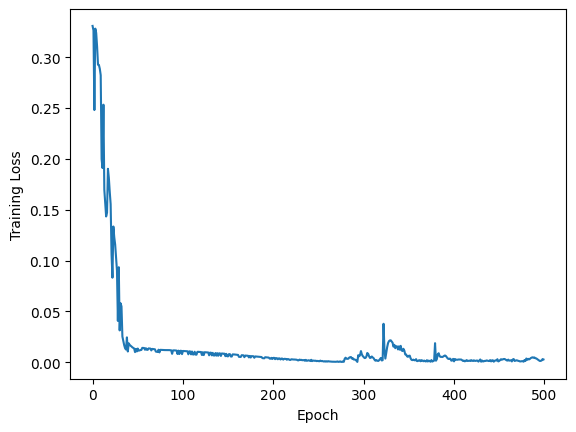

Learned reaction rates: [19402.668]
Reaction stoiciometry
[[-0.96363586]
 [-0.96363586]
 [ 0.9409687 ]
 [ 0.9409687 ]
 [ 0.02266726]]


In [12]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

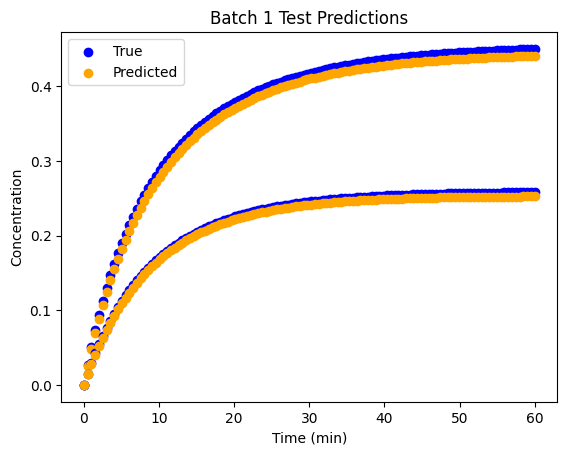

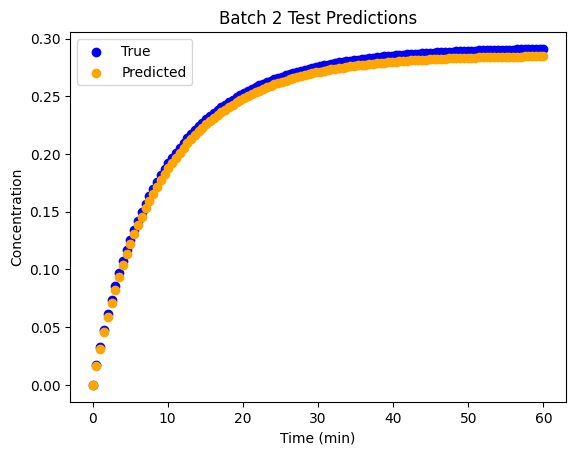

In [13]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

## all possible species with single atom counts

In [14]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 0, 1, 1, 0, 1],
    [0, 1, 1, 0, 1, 0, 1],
    [0, 1, 0, 1, 1, 1, 0]
])       # for scipy.null_spa


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true)
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.252438
Epoch 11/500 | loss 0.213316
Epoch 21/500 | loss 0.080131
Epoch 31/500 | loss 0.097406
Epoch 41/500 | loss 0.065461
Epoch 51/500 | loss 0.074020
Epoch 61/500 | loss 0.072223
Epoch 71/500 | loss 0.036429
Epoch 81/500 | loss 0.018846
Epoch 91/500 | loss 0.010216
Epoch 101/500 | loss 0.008041
Epoch 111/500 | loss 0.006741
Epoch 121/500 | loss 0.006736
Epoch 131/500 | loss 0.008356
Epoch 141/500 | loss 0.009901
Epoch 151/500 | loss 0.010730
Epoch 161/500 | loss 0.007619
Epoch 171/500 | loss 0.007312
Epoch 181/500 | loss 0.005997
Epoch 191/500 | loss 0.003537
Epoch 201/500 | loss 0.003274
Epoch 211/500 | loss 0.005181
Epoch 221/500 | loss 0.003639
Epoch 231/500 | loss 0.004142
Epoch 241/500 | loss 0.003541
Epoch 251/500 | loss 0.007689
Epoch 261/500 | loss 0.005954
Epoch 271/500 | loss 0.006389
Epoch 281/500 | loss 0.004823
Epoch 291/500 | loss 0.004899
Epoch 301/500 | loss 0.004347
Epoch 311/500 | loss 0.003967
Epoch 321/500 | loss 0.003662
Epoch 331/500 | loss 

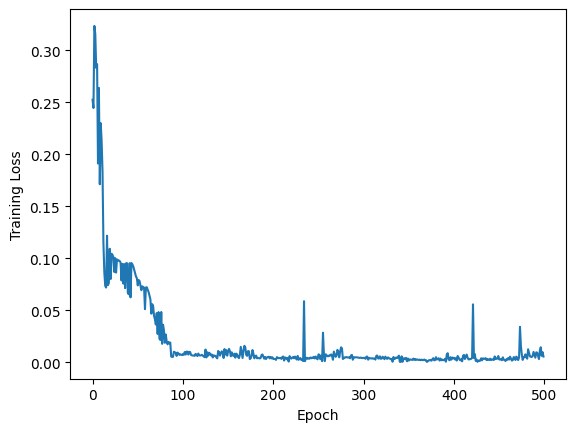

Learned reaction rates: [21615.176]
Reaction stoiciometry
[[-0.9047367 ]
 [-1.1787322 ]
 [ 0.9284594 ]
 [ 0.65446407]
 [ 0.16257149]
 [ 0.36169663]
 [ 0.08770122]]


In [15]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

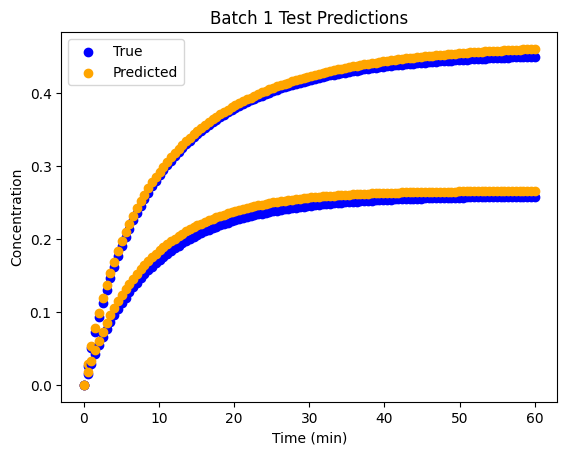

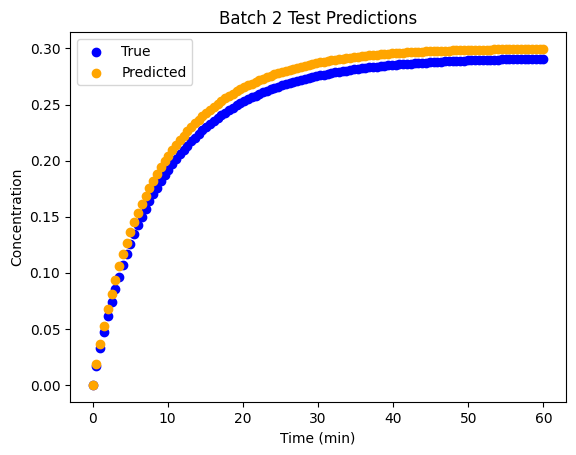

In [16]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

# With L1 regularization

In [17]:
lambda_l1 = 1e-4  

## Known species experiment

In [18]:
# global constants pulled from the *base dataset*
A_control = base_ds.get_A().detach().cpu().numpy()         # for scipy.null_spa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true) + lambda_l1 * model.nu().abs().sum()
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.330096
Epoch 11/500 | loss 0.230614
Epoch 21/500 | loss 0.081701
Epoch 31/500 | loss 0.054897
Epoch 41/500 | loss 0.014899
Epoch 51/500 | loss 0.010600
Epoch 61/500 | loss 0.007879
Epoch 71/500 | loss 0.004190
Epoch 81/500 | loss 0.004514
Epoch 91/500 | loss 0.001365
Epoch 101/500 | loss 0.000760
Epoch 111/500 | loss 0.000707
Epoch 121/500 | loss 0.000540
Epoch 131/500 | loss 0.000538
Epoch 141/500 | loss 0.000624
Epoch 151/500 | loss 0.000732
Epoch 161/500 | loss 0.000362
Epoch 171/500 | loss 0.000678
Epoch 181/500 | loss 0.000414
Epoch 191/500 | loss 0.000880
Epoch 201/500 | loss 0.000913
Epoch 211/500 | loss 0.000370
Epoch 221/500 | loss 0.000860
Epoch 231/500 | loss 0.000440
Epoch 241/500 | loss 0.000529
Epoch 251/500 | loss 0.001157
Epoch 261/500 | loss 0.000361
Epoch 271/500 | loss 0.000425
Epoch 281/500 | loss 0.000581
Epoch 291/500 | loss 0.000679
Epoch 301/500 | loss 0.000407
Epoch 311/500 | loss 0.000905
Epoch 321/500 | loss 0.001098
Epoch 331/500 | loss 

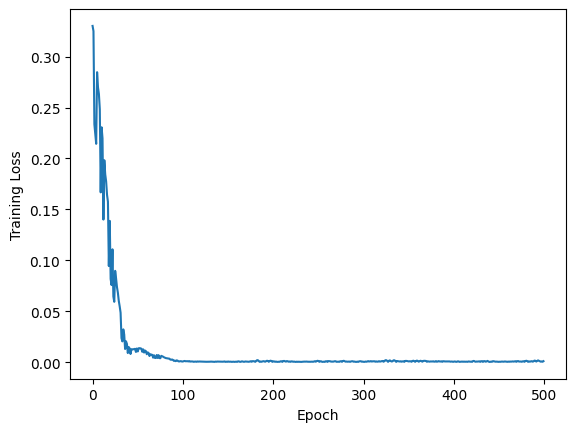

Learned reaction rates: [19815.762]
Reaction stoiciometry
[[-1.0041337]
 [-1.0041336]
 [ 1.0041337]]


In [19]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

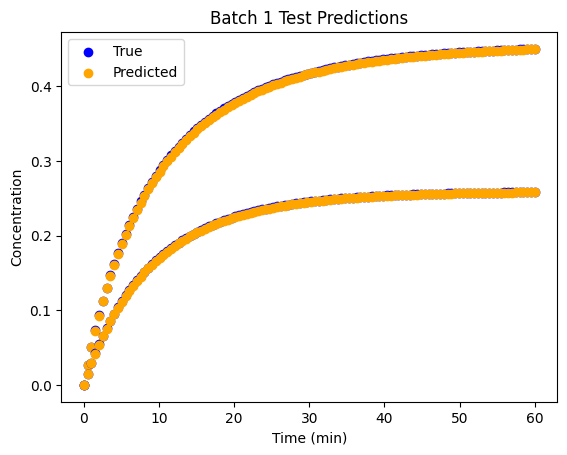

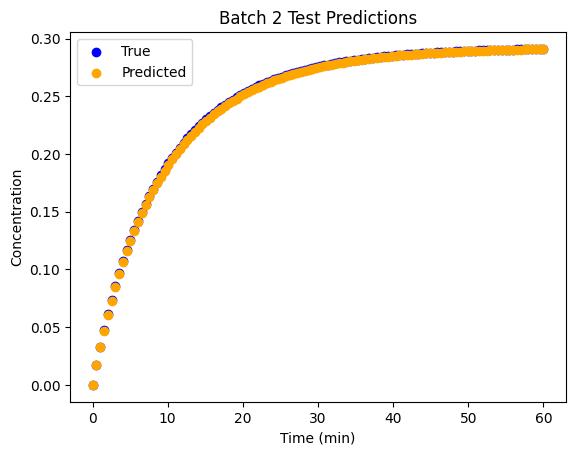

In [20]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

## Redundant species added

In [21]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 0, 1],
    [0, 1, 1, 0],
    [0, 1, 0, 1]
])       # for scipy.null_spa

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true) + lambda_l1 * model.nu().abs().sum()
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.252533
Epoch 11/500 | loss 0.239250
Epoch 21/500 | loss 0.134005
Epoch 31/500 | loss 0.029057
Epoch 41/500 | loss 0.015151
Epoch 51/500 | loss 0.014235
Epoch 61/500 | loss 0.011300
Epoch 71/500 | loss 0.007670
Epoch 81/500 | loss 0.003697
Epoch 91/500 | loss 0.003542
Epoch 101/500 | loss 0.001207
Epoch 111/500 | loss 0.001055
Epoch 121/500 | loss 0.000705
Epoch 131/500 | loss 0.000686
Epoch 141/500 | loss 0.000909
Epoch 151/500 | loss 0.000444
Epoch 161/500 | loss 0.000744
Epoch 171/500 | loss 0.001035
Epoch 181/500 | loss 0.001915
Epoch 191/500 | loss 0.000889
Epoch 201/500 | loss 0.001240
Epoch 211/500 | loss 0.000511
Epoch 221/500 | loss 0.001084
Epoch 231/500 | loss 0.001021
Epoch 241/500 | loss 0.000466
Epoch 251/500 | loss 0.000618
Epoch 261/500 | loss 0.000849
Epoch 271/500 | loss 0.000618
Epoch 281/500 | loss 0.000496
Epoch 291/500 | loss 0.000553
Epoch 301/500 | loss 0.000799
Epoch 311/500 | loss 0.000868
Epoch 321/500 | loss 0.001336
Epoch 331/500 | loss 

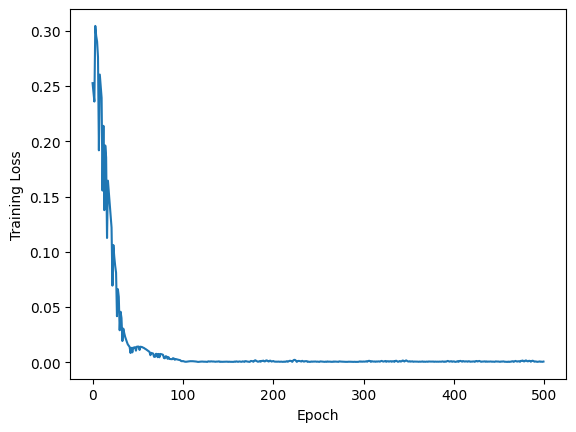

Learned reaction rates: [20088.475]
Reaction stoiciometry
[[-0.99811935]
 [-0.99811935]
 [ 0.99811935]
 [ 0.99811935]]


In [22]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

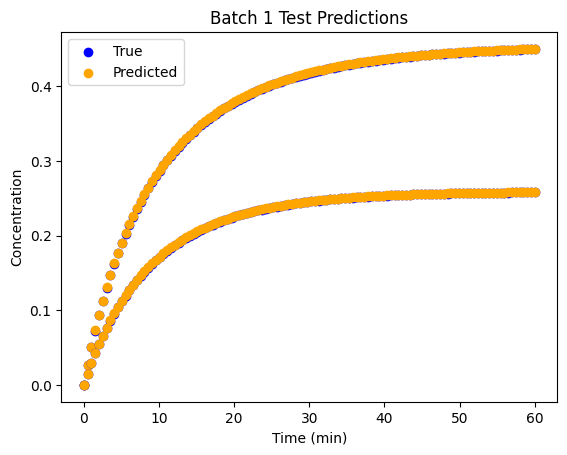

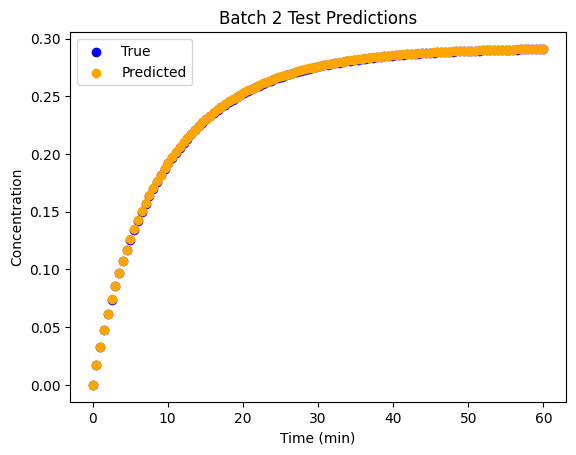

In [23]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

## Redundant species + possible latent species

In [24]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 0, 1, 1],
    [0, 1, 1, 0, 1],
    [0, 1, 0, 1, 1]
])       # for scipy.null_spa


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true) + lambda_l1 * model.nu().abs().sum()
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.251901
Epoch 11/500 | loss 0.181973
Epoch 21/500 | loss 0.141898
Epoch 31/500 | loss 0.049554
Epoch 41/500 | loss 0.016029
Epoch 51/500 | loss 0.014345
Epoch 61/500 | loss 0.014301
Epoch 71/500 | loss 0.013061
Epoch 81/500 | loss 0.012785
Epoch 91/500 | loss 0.012644
Epoch 101/500 | loss 0.012029
Epoch 111/500 | loss 0.011528
Epoch 121/500 | loss 0.007756
Epoch 131/500 | loss 0.010766
Epoch 141/500 | loss 0.009859
Epoch 151/500 | loss 0.009160
Epoch 161/500 | loss 0.008516
Epoch 171/500 | loss 0.007817
Epoch 181/500 | loss 0.007018
Epoch 191/500 | loss 0.006170
Epoch 201/500 | loss 0.004194
Epoch 211/500 | loss 0.003418
Epoch 221/500 | loss 0.004139
Epoch 231/500 | loss 0.003362
Epoch 241/500 | loss 0.002864
Epoch 251/500 | loss 0.002204
Epoch 261/500 | loss 0.001642
Epoch 271/500 | loss 0.001199
Epoch 281/500 | loss 0.000782
Epoch 291/500 | loss 0.004159
Epoch 301/500 | loss 0.006995
Epoch 311/500 | loss 0.004650
Epoch 321/500 | loss 0.007530
Epoch 331/500 | loss 

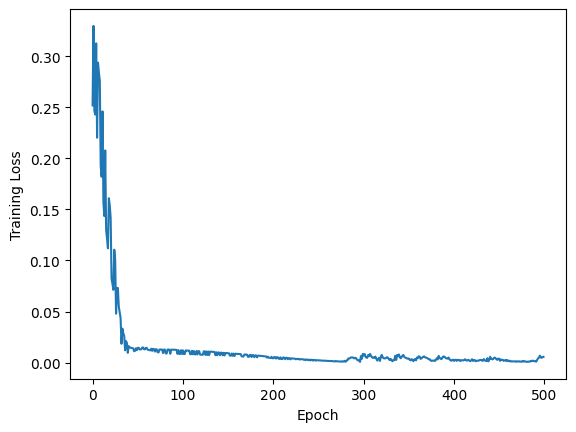

Learned reaction rates: [22575.938]
Reaction stoiciometry
[[-0.97696686]
 [-0.97696686]
 [ 0.96141195]
 [ 0.96141195]
 [ 0.01555488]]


In [25]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

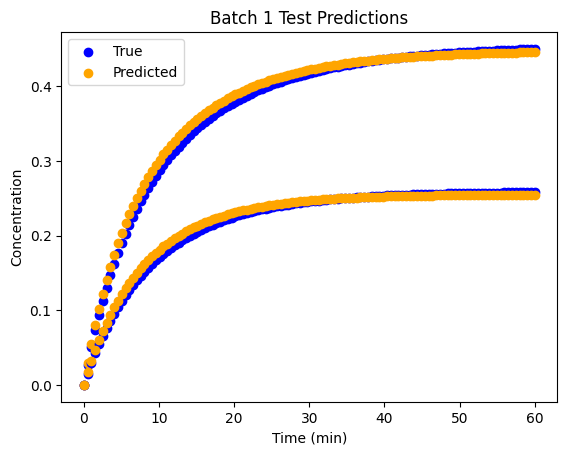

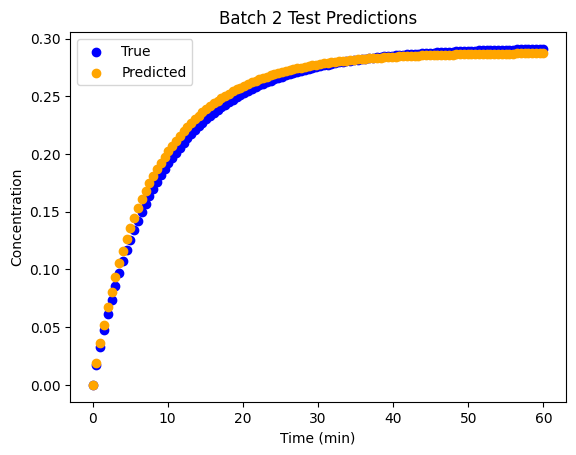

In [26]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

## all possible species with single atom counts

In [27]:
# global constants pulled from the *base dataset*
A_control = np.array([
    [1, 0, 0, 1, 1, 0, 1],
    [0, 1, 1, 0, 1, 0, 1],
    [0, 1, 0, 1, 1, 1, 0]
])       # for scipy.null_spa


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.9, 0.999), weight_decay=1e-8)

t_train = base_ds.get_t().to(device).float()

loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        #if there are not enough c0 for the control A add zeros
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device).float()

        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind] # (B, T, 1)
        loss_value = loss_fn(y_pred, y_true) + lambda_l1 * model.nu().abs().sum()
        loss_value.backward()
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")
        #print(f"    k: {1e9*np.exp(model.log_k.detach().cpu().numpy())}")
        #print(f"    Sum stoich:\n{np.sum(np.abs((model.nu().detach().cpu().numpy())))}\n")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/500 | loss 0.252633
Epoch 11/500 | loss 0.215823
Epoch 21/500 | loss 0.107004
Epoch 31/500 | loss 0.104681
Epoch 41/500 | loss 0.067517
Epoch 51/500 | loss 0.091645
Epoch 61/500 | loss 0.067816
Epoch 71/500 | loss 0.069695
Epoch 81/500 | loss 0.037843
Epoch 91/500 | loss 0.036739
Epoch 101/500 | loss 0.015689
Epoch 111/500 | loss 0.008716
Epoch 121/500 | loss 0.009261
Epoch 131/500 | loss 0.007719
Epoch 141/500 | loss 0.006474
Epoch 151/500 | loss 0.008572
Epoch 161/500 | loss 0.009060
Epoch 171/500 | loss 0.006955
Epoch 181/500 | loss 0.007275
Epoch 191/500 | loss 0.008910
Epoch 201/500 | loss 0.006432
Epoch 211/500 | loss 0.004569
Epoch 221/500 | loss 0.005502
Epoch 231/500 | loss 0.006221
Epoch 241/500 | loss 0.003653
Epoch 251/500 | loss 0.003449
Epoch 261/500 | loss 0.006334
Epoch 271/500 | loss 0.003354
Epoch 281/500 | loss 0.003255
Epoch 291/500 | loss 0.002763
Epoch 301/500 | loss 0.004375
Epoch 311/500 | loss 0.004346
Epoch 321/500 | loss 0.003363
Epoch 331/500 | loss 

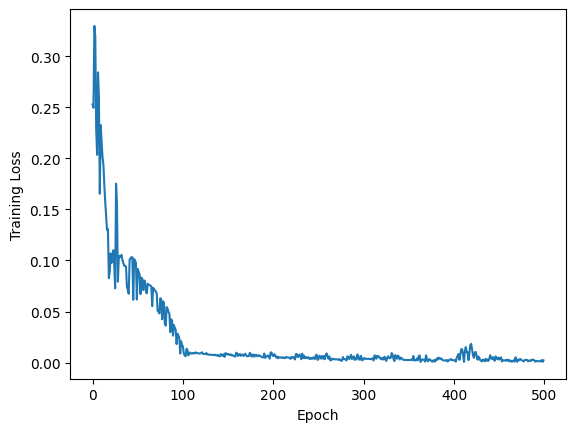

Learned reaction rates: [20518.764]
Reaction stoichiometry
[[-1.0035155 ]
 [-1.0515286 ]
 [ 1.0084686 ]
 [ 0.9604556 ]
 [ 0.01860806]
 [ 0.07246491]
 [ 0.02445181]]


In [28]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9/norm_value)  # in M^~-1 s^-1
print('Reaction stoichiometry')
print(-1*model.nu().detach().numpy())

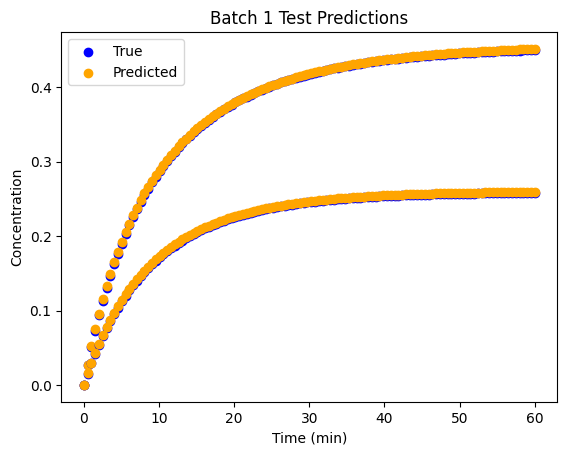

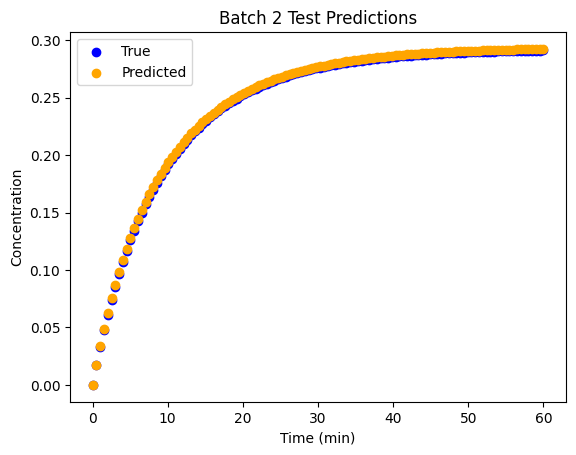

In [29]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        if c0.shape[1] < A_control.shape[1]:
            c0_padded = torch.zeros((c0.shape[0], A_control.shape[1]), device=device)
            c0_padded[:, :c0.shape[1]] = c0
            c0 = c0_padded
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()